# Mutual Fund Portfolio Constructor

End-to-end pipeline: universe filtering → factor scoring → overlap-constrained selection → allocation.

Design decisions: [`docs/portfolio_design_plan.md`](../docs/portfolio_design_plan.md)

---
**Run all cells top-to-bottom.** Change `PROFILE` in Section 0 to switch investor personas.


In [1]:
# ═══════════════════════════════════════════════════════════════
# Section 0 — Configuration
# All tunable parameters in one place.
# ═══════════════════════════════════════════════════════════════
from pathlib import Path

# Investor profile
PROFILE = "moderate"          # "conservative" | "moderate" | "aggressive"

# Data paths (relative to notebook location: mutualfunds/)
DATA_DIR      = Path(".")
MONEYCONTROL  = DATA_DIR / "all_funds_moneycontrol.tsv"
RAW_FUNDS     = DATA_DIR / "raw_funds.tsv"
FUND_INFO_DIR = DATA_DIR / "fund_info"

# Universe filters
CRISIL_MIN        = 4    # hard gate: minimum Crisil star rating
MIN_CATEGORY_SIZE = 5    # min funds in category for within-category percentile;
                         # falls back to tier-wide if below

# Portfolio construction
CATEGORY_CAP      = 3     # max funds per category in shortlist
OVERLAP_THRESHOLD = 40.0  # max allowed pairwise holding overlap (%)
ALLOC_FLOOR       = 0.05  # minimum allocation per fund
ALLOC_CAP         = 0.20  # maximum allocation per fund

# s_risk_adjusted component weights (must sum to 1.0)
RISK_WEIGHTS = {"sharpe_5y": 0.45, "sortino_3y": 0.35, "sharpe_3y": 0.20}

# Profile weight table — 5 factors, each row sums to 1.0
# Return cluster: conservative 45% | moderate 57% | aggressive 73%
# Risk cluster:   conservative 55% | moderate 43% | aggressive 27%
PROFILE_WEIGHTS = {
    "conservative": {
        "s_10Y": 0.25, "s_5Y": 0.15, "s_3Y": 0.05,
        "s_risk_adjusted": 0.32, "s_consistency": 0.23,
    },
    "moderate": {
        "s_10Y": 0.18, "s_5Y": 0.29, "s_3Y": 0.10,
        "s_risk_adjusted": 0.28, "s_consistency": 0.15,
    },
    "aggressive": {
        "s_10Y": 0.10, "s_5Y": 0.33, "s_3Y": 0.30,
        "s_risk_adjusted": 0.17, "s_consistency": 0.10,
    },
}

assert PROFILE in PROFILE_WEIGHTS, f"Unknown profile: {PROFILE}"
assert abs(sum(PROFILE_WEIGHTS[PROFILE].values()) - 1.0) < 1e-9, "Weights must sum to 1.0"

_w = PROFILE_WEIGHTS[PROFILE]
print(f"Profile  : {PROFILE}")
print(f"Weights  : {_w}")
print(f"Return cluster : {(_w['s_10Y']+_w['s_5Y']+_w['s_3Y'])*100:.0f}%")
print(f"Risk cluster   : {(_w['s_risk_adjusted']+_w['s_consistency'])*100:.0f}%")


Profile  : moderate
Weights  : {'s_10Y': 0.18, 's_5Y': 0.29, 's_3Y': 0.1, 's_risk_adjusted': 0.28, 's_consistency': 0.15}
Return cluster : 57%
Risk cluster   : 43%


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.1f}".format)

FACTOR_COLS = ["s_10Y", "s_5Y", "s_3Y", "s_risk_adjusted", "s_consistency"]


## Section 1 — Data Loading

In [3]:
# Load MoneyControl universe (returns, Crisil, Category)
mc = pd.read_csv(MONEYCONTROL, sep="\t")

RETURN_COLS = ["1W", "1M", "3M", "6M", "YTD", "1Y", "2Y", "3Y", "5Y", "10Y"]
for col in RETURN_COLS:
    mc[col] = pd.to_numeric(
        mc[col].astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce",
    )
mc["Crisil Rating"] = pd.to_numeric(mc["Crisil Rating"], errors="coerce")

# Cleaned short name for ISIN matching (same logic as fund_selection_strategy.ipynb)
def clean_name(s: str) -> str:
    import re
    s = re.sub(r"\s*-\s*Direct Plan.*", "", str(s), flags=re.IGNORECASE)
    s = re.sub(r"\s*-\s*Growth.*",      "", s,       flags=re.IGNORECASE)
    return s.strip()

mc["_short"] = mc["Scheme Name"].apply(clean_name)

print(f"MoneyControl universe: {len(mc)} funds")
print(f"Categories: {mc['Category Name'].nunique()}")
mc.head(3)


MoneyControl universe: 924 funds
Categories: 22


,Scheme Name,Plan,Category Name,Crisil Rating,AuM (Cr),1W,1M,3M,6M,YTD,1Y,2Y,3Y,5Y,10Y,_short
0,Mirae Asset NYSE FANG+ ETF FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,-0.6,1.0,-7.8,-7.2,-7.3,31.4,33.8,47.9,NaN,NaN,Mirae Asset NYSE FANG+ ETF FoF Dir Gr
1,DSP Wld Gld Mng Ovrs Eq Omni FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,3.9,-20.9,3.9,24.4,4.2,111.9,79.0,47.2,27.7,17.9,DSP Wld Gld Mng Ovrs Eq Omni FoF Dir Gr
2,Mirae Asset S&P 500 Top50 ETF FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,1.2,-3.4,-6.2,-0.5,-4.9,37.2,29.7,34.0,NaN,NaN,Mirae Asset S&P 500 Top50 ETF FoF Dir Gr


In [4]:
# Load raw_funds (ISIN bridge) and build name→ISIN mapping
raw = pd.read_csv(RAW_FUNDS, sep="\t")
raw["_short"] = raw["schemeName"].apply(clean_name)
name_to_isin  = raw.drop_duplicates("_short").set_index("_short")["isin"].to_dict()

# Merge ISINs into MoneyControl data
mc["isin"] = mc["_short"].map(name_to_isin)

matched   = mc["isin"].notna().sum()
unmatched = mc["isin"].isna().sum()
print(f"Total funds        : {len(mc)}")
print(f"ISIN matched       : {matched}")
print(f"ISIN unmatched     : {unmatched}  (no holdings data available — excluded)")


Total funds        : 924
ISIN matched       : 924
ISIN unmatched     : 0  (no holdings data available — excluded)


## Phase 0 — Universe Eligibility

In [5]:
n0 = len(mc)

mc = mc[mc["isin"].notna()].copy()
n1 = len(mc)

mc = mc[mc["Crisil Rating"] >= CRISIL_MIN].copy()
n2 = len(mc)

mc = mc[mc["5Y"].notna()].copy()
n3 = len(mc)

print(f"Starting universe           : {n0}")
print(f"After ISIN match required   : {n1}  (-{n0-n1})")
print(f"After Crisil >= {CRISIL_MIN}           : {n2}  (-{n1-n2})")
print(f"After 5Y return required    : {n3}  (-{n2-n3})")
print(f"\nEligible universe: {n3} funds")

universe = mc.reset_index(drop=True).copy()


Starting universe           : 924
After ISIN match required   : 924  (-0)
After Crisil >= 4           : 162  (-762)
After 5Y return required    : 140  (-22)

Eligible universe: 140 funds


## Phase 1 — Tier Assignment

In [6]:
def assign_tier(row) -> str:
    if pd.notna(row["10Y"]) and pd.notna(row["5Y"]):
        return "A"   # 10Y + 5Y: full history
    elif pd.notna(row["5Y"]):
        return "B"   # 5Y only: no 10Y
    return "C"       # should be unreachable after Phase 0

universe["tier"] = universe.apply(assign_tier, axis=1)

tier_summary = universe.groupby(["tier", "Category Name"]).size().unstack("tier", fill_value=0)
print(universe["tier"].value_counts().to_string())
print(f"\nTier A: have 10Y + 5Y data")
print(f"Tier B: have 5Y only, no 10Y (s_10Y weight redistributes to s_5Y + s_3Y)")
display(tier_summary)


tier
A    113
B     27

Tier A: have 10Y + 5Y data
Tier B: have 5Y only, no 10Y (s_10Y weight redistributes to s_5Y + s_3Y)


tier,A,B
Category Name,,
ELSS (Tax Savings),16,2
Equity - Consumption,5,2
Equity - ESG,1,3
Equity - Infrastructure,10,0
Flexi Cap,11,1
Focused Fund,6,5
Large & Mid-Cap,12,1
Large-Cap,16,2
Mid-Cap,11,3


## Phase 2 — Factor Score Computation

In [7]:
# ── Percentile rank helpers ──────────────────────────────────────────────────

def pct_rank(series: pd.Series) -> pd.Series:
    """0-100 percentile rank. NaN inputs remain NaN."""
    return series.rank(pct=True, method="average", ascending=True,
                       na_option="keep") * 100.0


def within_cat_pct(df: pd.DataFrame, col: str,
                   cat_col: str = "Category Name",
                   mask: pd.Series = None,
                   min_size: int = 5) -> pd.Series:
    """
    Percentile rank within category.
    mask  : optional boolean Series — limits which rows form the comparison
            universe AND receive scores (e.g. Tier A only for s_10Y).
    Fallback: if a category has fewer than min_size non-null rows,
              uses the full masked group (tier-wide) as the comparison universe.
    """
    source     = df if mask is None else df[mask]
    result     = pd.Series(np.nan, index=df.index)
    global_pct = pct_rank(source[col])          # tier-wide fallback

    for cat, grp in source.groupby(cat_col):
        n_valid = grp[col].dropna().shape[0]
        if n_valid >= min_size:
            result.loc[grp.index] = pct_rank(grp[col])
        else:
            result.loc[grp.index] = global_pct.loc[grp.index]

    return result

print("Helpers defined.")


Helpers defined.


In [8]:
# ── s_10Y: within (Tier A ∩ category) ────────────────────────────────────────
tier_a = universe["tier"] == "A"
universe["s_10Y"] = within_cat_pct(
    universe, "10Y",
    mask=tier_a, min_size=MIN_CATEGORY_SIZE,
)
# Tier B funds have NaN for s_10Y — weight redistributed in Phase 3

# ── s_5Y: within category, all eligible funds ─────────────────────────────────
universe["s_5Y"] = within_cat_pct(
    universe, "5Y", min_size=MIN_CATEGORY_SIZE,
)

# ── s_3Y: within category, all eligible funds ─────────────────────────────────
universe["s_3Y"] = within_cat_pct(
    universe, "3Y", min_size=MIN_CATEGORY_SIZE,
)

print("Return factor scores:")
print(universe[["tier", "s_10Y", "s_5Y", "s_3Y"]].describe().round(1))


Return factor scores:
       s_10Y  s_5Y  s_3Y
count  113.0 140.0 140.0
mean    54.5  53.6  53.4
std     28.8  29.4  29.2
min      1.8   0.7   3.6
25%     31.2  28.4  28.4
50%     54.5  54.2  53.7
75%     80.0  80.0  78.0
max    100.0 100.0 100.0


In [9]:
# ── Load risk_metrics_{isin}.tsv for all eligible funds ──────────────────────

def load_risk_metrics(isin: str) -> dict:
    f = FUND_INFO_DIR / f"risk_metrics_{isin}.tsv"
    if not f.exists():
        return {"sharpe_3y": np.nan, "sharpe_5y": np.nan, "sortino_3y": np.nan}
    df = pd.read_csv(f, sep="\t")
    if df.empty:
        return {"sharpe_3y": np.nan, "sharpe_5y": np.nan, "sortino_3y": np.nan}
    row = df.iloc[0]
    return {
        "sharpe_3y":  pd.to_numeric(row.get("sharpe_3y"),  errors="coerce"),
        "sharpe_5y":  pd.to_numeric(row.get("sharpe_5y"),  errors="coerce"),
        "sortino_3y": pd.to_numeric(row.get("sortino_3y"), errors="coerce"),
    }

risk_rows = [{"isin": isin, **load_risk_metrics(isin)} for isin in universe["isin"]]
risk_df   = pd.DataFrame(risk_rows)
universe  = universe.merge(risk_df, on="isin", how="left")

missing = universe[["sharpe_3y", "sharpe_5y", "sortino_3y"]].isna().sum()
print(f"Risk metrics loaded. Missing values:")
print(missing.to_string())


Risk metrics loaded. Missing values:
sharpe_3y     96
sharpe_5y     96
sortino_3y    96


In [10]:
# ── s_risk_adjusted = 0.45×Sharpe_5Y_pct + 0.35×Sortino_3Y_pct + 0.20×Sharpe_3Y_pct
# Each component percentile-normalised within category before blending.
# Missing Sharpe_5Y: its 0.45 weight redistributes proportionally to the other two.

universe["_sp5_pct"] = within_cat_pct(universe, "sharpe_5y",  min_size=MIN_CATEGORY_SIZE)
universe["_so3_pct"] = within_cat_pct(universe, "sortino_3y", min_size=MIN_CATEGORY_SIZE)
universe["_sp3_pct"] = within_cat_pct(universe, "sharpe_3y",  min_size=MIN_CATEGORY_SIZE)

def blend_risk(row) -> float:
    components = [
        (row["_sp5_pct"], RISK_WEIGHTS["sharpe_5y"]),
        (row["_so3_pct"], RISK_WEIGHTS["sortino_3y"]),
        (row["_sp3_pct"], RISK_WEIGHTS["sharpe_3y"]),
    ]
    avail = [(v, w) for v, w in components if pd.notna(v)]
    if not avail:
        return np.nan
    total_w = sum(w for _, w in avail)
    return sum(v * w for v, w in avail) / total_w

universe["s_risk_adjusted"] = universe.apply(blend_risk, axis=1)
universe.drop(columns=["_sp5_pct", "_so3_pct", "_sp3_pct"], inplace=True)

print("s_risk_adjusted:")
print(universe["s_risk_adjusted"].describe().round(1))


s_risk_adjusted:
count    44.0
mean     49.4
std      28.4
min       2.3
25%      23.9
50%      50.0
75%      73.1
max     100.0
Name: s_risk_adjusted, dtype: float64


In [11]:
# ── s_consistency: inverse-CV percentile within category
# CV = std / |mean| over {1Y, 2Y, 3Y, 5Y [, 10Y]} return horizons.
# This measures *horizon consistency* (does the fund perform well across
# different time frames?), not intra-period volatility.
# Cap CV at 99th percentile before inversion to prevent instability.

CV_HORIZONS = ["1Y", "2Y", "3Y", "5Y"]   # base; 10Y added for Tier A funds

def compute_cv(row) -> float:
    cols = CV_HORIZONS + (["10Y"] if pd.notna(row["10Y"]) else [])
    vals = pd.to_numeric(pd.Series([row[c] for c in cols]), errors="coerce").dropna()
    if len(vals) < 2 or vals.mean() == 0:
        return np.nan
    return float(vals.std() / abs(vals.mean()))

universe["_cv"] = universe.apply(compute_cv, axis=1)

# Cap extreme CVs and invert (lower CV = more consistent = better score)
cv_cap = universe["_cv"].quantile(0.99)
universe["_cv_capped"] = universe["_cv"].clip(upper=cv_cap)
universe["_inv_cv"]    = (1.0 / universe["_cv_capped"].replace(0, np.nan))

universe["s_consistency"] = within_cat_pct(universe, "_inv_cv", min_size=MIN_CATEGORY_SIZE)
universe.drop(columns=["_cv", "_cv_capped", "_inv_cv"], inplace=True)

print("s_consistency:")
print(universe["s_consistency"].describe().round(1))


s_consistency:
count   140.0
mean     53.2
std      29.4
min       5.6
25%      27.8
50%      54.2
75%      78.9
max     100.0
Name: s_consistency, dtype: float64


In [12]:
# ── Factor score summary ─────────────────────────────────────────────────────
summary = universe[[
    "_short", "Category Name", "tier", "Crisil Rating",
    "5Y", "10Y",
] + FACTOR_COLS].sort_values("s_5Y", ascending=False)

display(
    summary.head(40)
    .rename(columns={"_short": "Fund", "Category Name": "Category",
                     "Crisil Rating": "Crisil"})
    .style
    .format({c: "{:.0f}" for c in FACTOR_COLS}, na_rep="-")
    .format({"5Y": "{:.1f}%", "10Y": "{:.1f}%"}, na_rep="-")
    .background_gradient(subset=FACTOR_COLS, cmap="YlGn", vmin=0, vmax=100)
    .hide(axis="index")
)


Fund,Category,tier,Crisil,5Y,10Y,s_10Y,s_5Y,s_3Y,s_risk_adjusted,s_consistency
Nippon India Multi Cap Dir Gr,Multi-Cap,A,4.000000,19.7%,15.7%,51.327434,100.000000,100.000000,48.977273,80.000000
Nippon India Banking & Fin Srvs Dir Gr,Sector - Financial Services,A,4.000000,15.1%,14.5%,44.444444,100.000000,60.000000,-,60.000000
Nippon India Consumption Dir Gr,Equity - Consumption,A,4.000000,14.6%,13.6%,20.000000,100.000000,42.857143,-,42.857143
Quant ELSS Tax Saver Dir Gr,ELSS (Tax Savings),A,5.000000,17.9%,20.1%,100.000000,100.000000,55.555556,23.409091,55.555556
HDFC Flexi Cap Dir Gr,Flexi Cap,A,5.000000,18.7%,16.7%,72.727273,100.000000,91.666667,96.000000,75.000000
HDFC Focused Dir Gr,Focused Fund,A,5.000000,20.1%,15.5%,66.666667,100.000000,81.818182,100.000000,63.636364
Quant Small Cap Dir Gr,Small-Cap,A,4.000000,23.0%,18.1%,50.000000,100.000000,45.454545,58.125000,18.181818
Nippon India Large Cap Dir Gr,Large-Cap,A,5.000000,15.9%,14.9%,100.000000,100.000000,100.000000,32.954545,88.888889
ICICI Pru Infrastructure Dir Gr,Equity - Infrastructure,A,5.000000,24.4%,18.1%,70.000000,100.000000,50.000000,73.636364,50.000000
HSBC Value Dir Gr,Value,A,5.000000,18.5%,16.7%,100.000000,100.000000,100.000000,79.545455,85.714286


## Phase 3 — Profile-Driven Composite Score

In [13]:
base_w = PROFILE_WEIGHTS[PROFILE].copy()

def effective_weights(tier: str) -> dict:
    """
    For Tier B: redistribute s_10Y weight to s_5Y and s_3Y only.
    s_risk_adjusted and s_consistency remain at base profile weights.
    This keeps the risk cluster weight stable — missing 10Y is a return gap,
    not a risk gap.
    """
    w = base_w.copy()
    if tier == "B":
        w10 = w.pop("s_10Y")
        w5, w3 = w["s_5Y"], w["s_3Y"]
        denom = w5 + w3
        w["s_5Y"]  = w5 + w10 * (w5 / denom)
        w["s_3Y"]  = w3 + w10 * (w3 / denom)
    return w


def composite_score(row) -> float:
    w = effective_weights(row["tier"])
    total_w = total_s = 0.0
    for factor, weight in w.items():
        val = row.get(factor)
        if pd.notna(val) and weight > 0:
            total_s += weight * val
            total_w += weight
    return (total_s / total_w) if total_w > 0 else np.nan


universe["composite"] = universe.apply(composite_score, axis=1)

# Show effective weight split for each tier
print(f"Tier A effective weights: {effective_weights('A')}")
print(f"Tier B effective weights: {effective_weights('B')}")
print(f"\nComposite score distribution:")
print(universe["composite"].describe().round(1))


Tier A effective weights: {'s_10Y': 0.18, 's_5Y': 0.29, 's_3Y': 0.1, 's_risk_adjusted': 0.28, 's_consistency': 0.15}
Tier B effective weights: {'s_5Y': 0.4238461538461538, 's_3Y': 0.14615384615384616, 's_risk_adjusted': 0.28, 's_consistency': 0.15}

Composite score distribution:
count   140.0
mean     51.3
std      20.2
min       4.0
25%      36.3
50%      52.5
75%      66.3
max      92.1
Name: composite, dtype: float64


## Phase 4 — Category-Aware Shortlisting

In [14]:
shortlist = (
    universe
    .sort_values("composite", ascending=False)
    .groupby("Category Name", group_keys=False)
    .head(CATEGORY_CAP)
    .sort_values("composite", ascending=False)
    .reset_index(drop=True)
)

print(f"Shortlisted: {len(shortlist)} funds across "
      f"{shortlist['Category Name'].nunique()} categories  "
      f"(max {CATEGORY_CAP} per category)")
print()
print(shortlist["Category Name"].value_counts().to_string())

display(
    shortlist[["_short", "Category Name", "tier", "composite"] + FACTOR_COLS]
    .rename(columns={"_short": "Fund", "Category Name": "Category"})
    .style
    .format({"composite": "{:.1f}", **{c: "{:.0f}" for c in FACTOR_COLS}}, na_rep="-")
    .background_gradient(subset=["composite"], cmap="YlGn")
    .hide(axis="index")
)


Shortlisted: 39 funds across 13 categories  (max 3 per category)

Category Name
Value                          3
Flexi Cap                      3
Large & Mid-Cap                3
Small-Cap                      3
Focused Fund                   3
Mid-Cap                        3
Large-Cap                      3
Sector - Financial Services    3
Equity - Infrastructure        3
ELSS (Tax Savings)             3
Multi-Cap                      3
Equity - Consumption           3
Equity - ESG                   3


Fund,Category,tier,composite,s_10Y,s_5Y,s_3Y,s_risk_adjusted,s_consistency
HSBC Value Dir Gr,Value,A,92.1,100,100,100,80,86
HDFC Flexi Cap Dir Gr,Flexi Cap,A,89.4,73,100,92,96,75
Bandhan Large & Mid Cap Dir Gr,Large & Mid-Cap,A,88.6,92,85,92,88,92
Bandhan Small Cap Dir Gr,Small-Cap,B,88.6,-,91,100,83,82
HDFC Focused Dir Gr,Focused Fund,A,86.7,67,100,82,100,64
Parag Parikh Flexi Cap Dir Gr,Flexi Cap,A,82.5,91,75,83,84,83
Motilal Oswal Large & Midcap Dir Gr,Large & Mid-Cap,B,81.9,-,100,100,60,54
HDFC Mid Cap Dir Gr,Mid-Cap,A,81.3,64,96,54,100,57
ICICI Pru Focused Equity Dir Gr,Focused Fund,A,80.9,83,82,100,71,82
Nippon India Growth Mid Cap Dir Gr,Mid-Cap,A,80.8,82,96,93,76,50


## Phase 5 — Overlap-Constrained Portfolio Selection

In [15]:
# ── Load holdings for all shortlisted funds ──────────────────────────────────

def load_holdings(isin: str) -> dict:
    """Returns {stock_name: fraction} normalised to sum=1.0. Empty dict if unavailable."""
    f = FUND_INFO_DIR / f"holdings_{isin}.tsv"
    if not f.exists():
        return {}
    df = pd.read_csv(f, sep="\t")
    if df.empty or "weight" not in df.columns:
        return {}
    df["weight"] = pd.to_numeric(
        df["weight"].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    ).fillna(0.0)
    # Aggregate across all time-period rows for each stock, then normalise to 1.0
    h     = df.groupby("stock_name")["weight"].sum().to_dict()
    total = sum(h.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in h.items()}

holdings_map = {isin: load_holdings(isin) for isin in shortlist["isin"]}

no_holdings = [isin for isin, h in holdings_map.items() if not h]
if no_holdings:
    print(f"⚠  No holdings data for {len(no_holdings)} fund(s) — removing from shortlist:")
    for isin in no_holdings:
        name = shortlist.loc[shortlist["isin"] == isin, "_short"].values[0]
        print(f"   {isin}  {name}")
    shortlist = shortlist[~shortlist["isin"].isin(no_holdings)].reset_index(drop=True)

print(f"Holdings loaded for {len(shortlist)} funds.")


⚠  No holdings data for 12 fund(s) — removing from shortlist:
   INF205K013T3  Invesco India Smallcap Dir Gr
   INF769K01GX9  Mirae Asset Banking & Fin Svcs Dir Gr
   INF740K01OK1  DSP ELSS Tax Saver Dir Gr
   INF204K01XO1  Nippon India Banking & Fin Srvs Dir Gr
   INF200K01UM9  SBI ELSS Tax Saver Dir Gr
   INF194K01Z44  Bandhan Large Cap Dir Gr
   INF109K012K1  ICICI Prudential Value Dir Gr
   INF740KA1PP3  DSP Value Dir Gr
   INF204K01G52  Nippon India Consumption Dir Gr
   INF109K014O9  ICICI Pru Multicap Dir Gr
   INF109KC1O09  ICICI Pru ESG Exclsnry Strtgy Dir Gr
   INF174KA1FI4  Kotak ESG Exclusionary Strategy Dir Gr
Holdings loaded for 27 funds.


In [16]:
# ── Pairwise overlap matrix ───────────────────────────────────────────────────

def pairwise_overlap(ha: dict, hb: dict) -> float:
    """Sørensen: sum of min(w_a, w_b) for common holdings × 100 → percentage."""
    if not ha or not hb:
        return 50.0    # neutral fallback for missing data
    common = set(ha) & set(hb)
    return sum(min(ha[s], hb[s]) for s in common) * 100.0

isins = shortlist["isin"].tolist()
n     = len(isins)

ov_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        ov = pairwise_overlap(holdings_map[isins[i]], holdings_map[isins[j]])
        ov_matrix[i, j] = ov
        ov_matrix[j, i] = ov
np.fill_diagonal(ov_matrix, 100.0)

overlap_df = pd.DataFrame(ov_matrix, index=isins, columns=isins)

high_pairs = [
    (isins[i], isins[j], ov_matrix[i, j])
    for i in range(n) for j in range(i + 1, n)
    if ov_matrix[i, j] > OVERLAP_THRESHOLD
]
print(f"Overlap matrix: {n}×{n}")
print(f"Pairs exceeding {OVERLAP_THRESHOLD:.0f}% threshold: {len(high_pairs)}")
if high_pairs:
    for a, b, ov in sorted(high_pairs, key=lambda x: -x[2])[:10]:
        na = shortlist.loc[shortlist['isin']==a, '_short'].values[0]
        nb = shortlist.loc[shortlist['isin']==b, '_short'].values[0]
        print(f"   {ov:.1f}%  {na}  ×  {nb}")


Overlap matrix: 27×27
Pairs exceeding 40% threshold: 10
   76.2%  HDFC Flexi Cap Dir Gr  ×  HDFC Focused Dir Gr
   73.6%  Motilal Oswal Large & Midcap Dir Gr  ×  Motilal Oswal ELSS Tax Saver Dir Gr
   54.8%  Nippon India Large Cap Dir Gr  ×  ICICI Prudential Large Cap Dir Gr
   54.8%  Nippon India Large Cap Dir Gr  ×  Nippon India Multi Cap Dir Gr
   48.2%  Nippon India Large Cap Dir Gr  ×  Mahindra Manulife Focused Dir Gr
   44.9%  Nippon India Growth Mid Cap Dir Gr  ×  Edelweiss Mid Cap Dir Gr
   42.7%  HDFC Flexi Cap Dir Gr  ×  Nippon India Large Cap Dir Gr
   42.5%  ICICI Pru Focused Equity Dir Gr  ×  ICICI Prudential Large Cap Dir Gr
   40.9%  Mahindra Manulife Focused Dir Gr  ×  ICICI Prudential Large Cap Dir Gr
   40.2%  HDFC Flexi Cap Dir Gr  ×  ICICI Prudential Large Cap Dir Gr


In [17]:
# ── Overlap-constrained selection — backtracking with branch-and-bound ─────────
# Objective: maximise Σ composite_score_i
# Constraint: pairwise overlap(i,j) ≤ OVERLAP_THRESHOLD for all pairs in S

score_map    = dict(zip(shortlist["isin"], shortlist["composite"]))
sorted_isins = shortlist.sort_values("composite", ascending=False)["isin"].tolist()

# O(1) overlap lookup
ov_lookup = {i: {j: overlap_df.loc[i, j] for j in isins} for i in isins}

best_sel   = []
best_score = -1.0

def backtrack(current: list, start: int, cur_score: float) -> None:
    global best_sel, best_score

    if cur_score > best_score and current:
        best_score = cur_score
        best_sel   = current.copy()

    # Branch-and-bound: prune if theoretical max future gain can't beat best
    future_ub = cur_score + sum(
        score_map[sorted_isins[k]] for k in range(start, len(sorted_isins))
    )
    if future_ub <= best_score and current:
        return

    for i in range(start, len(sorted_isins)):
        cand = sorted_isins[i]
        # Reject candidate if it violates overlap with any already-selected fund
        if any(ov_lookup[cand][sel] > OVERLAP_THRESHOLD for sel in current):
            continue
        current.append(cand)
        backtrack(current, i + 1, cur_score + score_map[cand])
        current.pop()

print(f"Optimising over {len(sorted_isins)} shortlisted funds...")
backtrack([], 0, 0.0)

if not best_sel:
    raise ValueError(
        f"No valid portfolio found at OVERLAP_THRESHOLD={OVERLAP_THRESHOLD}. "
        "Try raising OVERLAP_THRESHOLD."
    )

selected = shortlist[shortlist["isin"].isin(best_sel)].copy()
print(f"\n✓  Selected {len(selected)} funds  |  Portfolio score sum: {best_score:.2f}")
print()
print(
    selected[["_short", "Category Name", "tier", "composite"]]
    .rename(columns={"_short": "Fund", "Category Name": "Category"})
    .to_string(index=False)
)


Optimising over 27 shortlisted funds...

✓  Selected 22 funds  |  Portfolio score sum: 1681.93

                                 Fund                    Category tier  composite
                    HSBC Value Dir Gr                       Value    A       92.1
                HDFC Flexi Cap Dir Gr                   Flexi Cap    A       89.4
       Bandhan Large & Mid Cap Dir Gr             Large & Mid-Cap    A       88.6
             Bandhan Small Cap Dir Gr                   Small-Cap    B       88.6
        Parag Parikh Flexi Cap Dir Gr                   Flexi Cap    A       82.5
  Motilal Oswal Large & Midcap Dir Gr             Large & Mid-Cap    B       81.9
                  HDFC Mid Cap Dir Gr                     Mid-Cap    A       81.3
      ICICI Pru Focused Equity Dir Gr                Focused Fund    A       80.9
   Nippon India Growth Mid Cap Dir Gr                     Mid-Cap    A       80.8
        Nippon India Small Cap Dir Gr                   Small-Cap    A       80.3
  

## Phase 6 — Score-Proportional Weight Allocation

In [18]:
def clip_and_renormalize(weights: dict, floor: float, cap: float,
                          max_iter: int = 50) -> dict:
    """Iteratively clip to [floor, cap] and renormalize until stable."""
    w = dict(weights)
    for _ in range(max_iter):
        total   = sum(w.values())
        w       = {k: v / total for k, v in w.items()}
        clipped = {k: min(max(v, floor), cap) for k, v in w.items()}
        if all(abs(clipped[k] - w[k]) < 1e-9 for k in w):
            break
        w = clipped
    total = sum(w.values())
    return {k: v / total for k, v in w.items()}

raw_w   = {isin: score_map[isin] for isin in best_sel}
final_w = clip_and_renormalize(raw_w, ALLOC_FLOOR, ALLOC_CAP)
selected["allocation"] = selected["isin"].map(final_w)

print(f"Allocations (floor={ALLOC_FLOOR*100:.0f}%, cap={ALLOC_CAP*100:.0f}%):")
for _, row in selected.sort_values("allocation", ascending=False).iterrows():
    bar = "█" * int(row["allocation"] * 100 / 2)
    print(f"  {row['allocation']*100:5.1f}%  {bar}  {row['_short']}")
print(f"\n  Total: {sum(final_w.values())*100:.1f}%")


Allocations (floor=5%, cap=20%):
    4.5%  ██  HSBC Value Dir Gr
    4.5%  ██  HDFC Flexi Cap Dir Gr
    4.5%  ██  Bandhan Large & Mid Cap Dir Gr
    4.5%  ██  Bandhan Small Cap Dir Gr
    4.5%  ██  Parag Parikh Flexi Cap Dir Gr
    4.5%  ██  Motilal Oswal Large & Midcap Dir Gr
    4.5%  ██  HDFC Mid Cap Dir Gr
    4.5%  ██  ICICI Pru Focused Equity Dir Gr
    4.5%  ██  Nippon India Growth Mid Cap Dir Gr
    4.5%  ██  Nippon India Small Cap Dir Gr
    4.5%  ██  ICICI Pru Large & Mid Cap Dir Gr
    4.5%  ██  Invesco India Financial Serv Dir Gr
    4.5%  ██  ICICI Pru Infrastructure Dir Gr
    4.5%  ██  Nippon India Multi Cap Dir Gr
    4.5%  ██  Bank of India Manfactrg &Infra Dir Gr
    4.5%  ██  Franklin Build India Dir Gr
    4.5%  ██  Mahindra Manulife Focused Dir Gr
    4.5%  ██  Mahindra Manulife Multi Cap Dir Gr
    4.5%  ██  Bank of India Flexi Cap Fund Dir Gr
    4.5%  ██  Mirae Asset Great Consumer Dir Gr
    4.5%  ██  Tata India Consumer Dir Gr
    4.5%  ██  Quant ESG Integrat

## Section 9 — Final Portfolio

In [19]:
portfolio = (
    selected[[
        "_short", "Category Name", "tier", "Crisil Rating",
        "composite", "s_10Y", "s_5Y", "s_3Y", "s_risk_adjusted", "s_consistency",
        "allocation", "isin",
    ]]
    .rename(columns={
        "_short":        "Fund",
        "Category Name": "Category",
        "Crisil Rating": "Crisil",
    })
    .sort_values("allocation", ascending=False)
    .reset_index(drop=True)
)
portfolio.index += 1
portfolio["Alloc %"] = (portfolio["allocation"] * 100).round(1)

print(f"{'='*70}")
print(f"  FINAL PORTFOLIO  |  Profile: {PROFILE.upper()}  |  {len(portfolio)} funds")
print(f"{'='*70}\n")

display(
    portfolio[["Fund", "Category", "tier", "Crisil", "Alloc %",
               "composite", "s_10Y", "s_5Y", "s_3Y", "s_risk_adjusted", "s_consistency"]]
    .rename(columns={"tier": "Tier"})
    .style
    .format({
        "Alloc %":        "{:.1f}%",
        "composite":      "{:.1f}",
        **{c: "{:.0f}" for c in FACTOR_COLS},
    }, na_rep="-")
    .background_gradient(subset=["Alloc %", "composite"], cmap="YlGn")
    .hide(axis="index")
)

# Weighted-average factor scores
print("\nPortfolio weighted-average factor scores:")
for col in ["composite"] + FACTOR_COLS:
    valid = portfolio[col].notna()
    wa = np.average(portfolio.loc[valid, col], weights=portfolio.loc[valid, "allocation"])
    print(f"  {col:<22}: {wa:.1f}")

_w = PROFILE_WEIGHTS[PROFILE]
print(f"\nProfile weight split — "
      f"Return {(_w['s_10Y']+_w['s_5Y']+_w['s_3Y'])*100:.0f}%  |  "
      f"Risk {(_w['s_risk_adjusted']+_w['s_consistency'])*100:.0f}%")


  FINAL PORTFOLIO  |  Profile: MODERATE  |  22 funds



Fund,Category,Tier,Crisil,Alloc %,composite,s_10Y,s_5Y,s_3Y,s_risk_adjusted,s_consistency
HSBC Value Dir Gr,Value,A,5.000000,4.5%,92.1,100,100,100,80,86
HDFC Flexi Cap Dir Gr,Flexi Cap,A,5.000000,4.5%,89.4,73,100,92,96,75
Bandhan Large & Mid Cap Dir Gr,Large & Mid-Cap,A,5.000000,4.5%,88.6,92,85,92,88,92
Bandhan Small Cap Dir Gr,Small-Cap,B,5.000000,4.5%,88.6,-,91,100,83,82
Parag Parikh Flexi Cap Dir Gr,Flexi Cap,A,5.000000,4.5%,82.5,91,75,83,84,83
Motilal Oswal Large & Midcap Dir Gr,Large & Mid-Cap,B,5.000000,4.5%,81.9,-,100,100,60,54
HDFC Mid Cap Dir Gr,Mid-Cap,A,5.000000,4.5%,81.3,64,96,54,100,57
ICICI Pru Focused Equity Dir Gr,Focused Fund,A,5.000000,4.5%,80.9,83,82,100,71,82
Nippon India Growth Mid Cap Dir Gr,Mid-Cap,A,5.000000,4.5%,80.8,82,96,93,76,50
Nippon India Small Cap Dir Gr,Small-Cap,A,5.000000,4.5%,80.3,100,82,82,74,64



Portfolio weighted-average factor scores:
  composite             : 76.5
  s_10Y                 : 82.6
  s_5Y                  : 85.9
  s_3Y                  : 83.8
  s_risk_adjusted       : 62.8
  s_consistency         : 70.5

Profile weight split — Return 57%  |  Risk 43%


## Visualisations

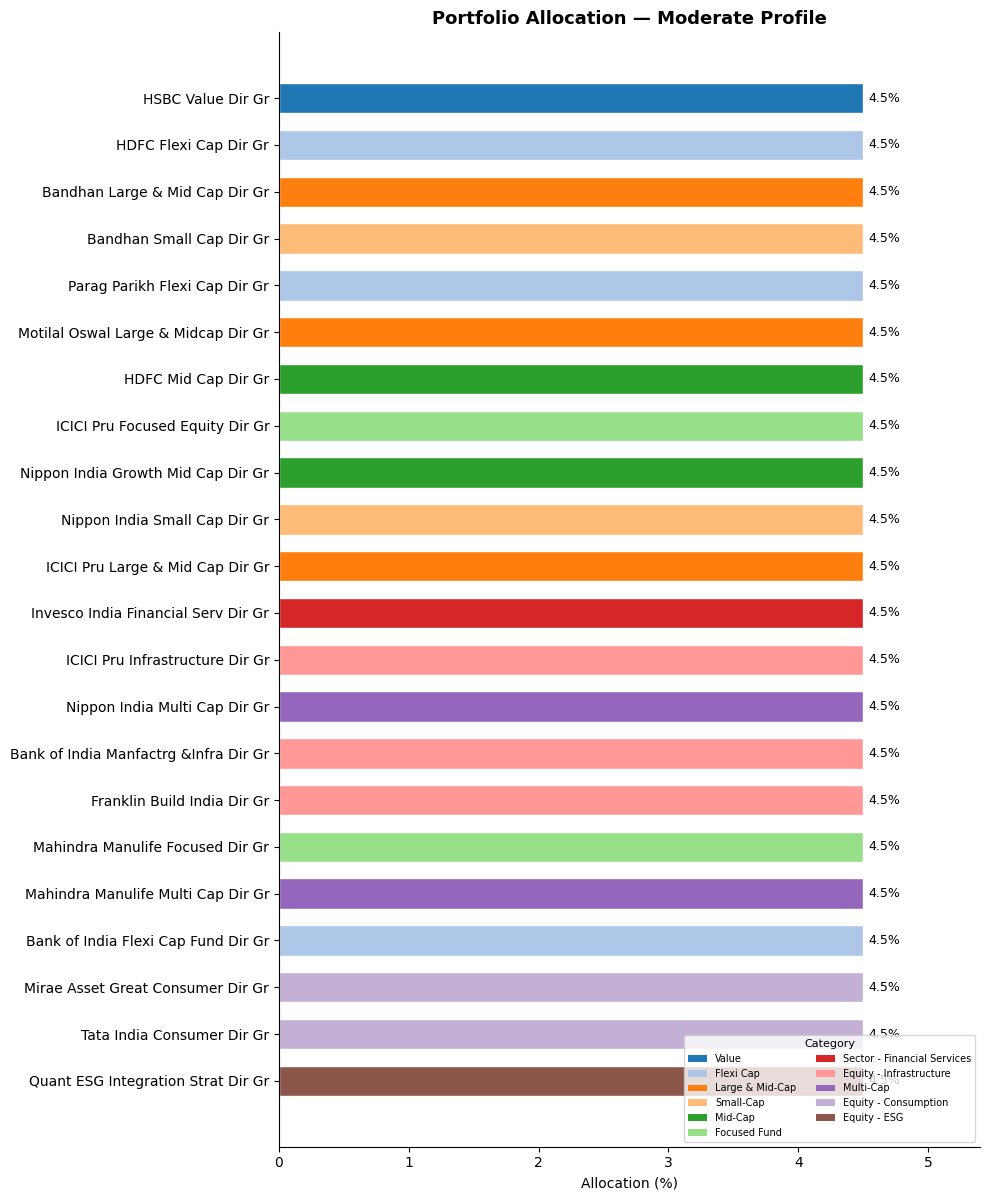

In [20]:
# ── Allocation bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(4, len(portfolio) * 0.55)))

funds  = portfolio["Fund"].tolist()
allocs = portfolio["Alloc %"].tolist()
cats   = portfolio["Category"].tolist()
ucats  = list(dict.fromkeys(cats))
pal    = sns.color_palette("tab20", len(ucats))
cmap   = dict(zip(ucats, pal))
colors = [cmap[c] for c in cats]

bars = ax.barh(funds, allocs, color=colors, edgecolor="white", height=0.65)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_xlabel("Allocation (%)")
ax.set_title(f"Portfolio Allocation — {PROFILE.capitalize()} Profile",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, max(allocs) * 1.20)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
handles = [Patch(facecolor=cmap[c], label=c) for c in ucats]
ax.legend(handles=handles, loc="lower right", fontsize=7, title="Category",
          title_fontsize=8, ncol=2, framealpha=0.8)

plt.tight_layout()
plt.show()


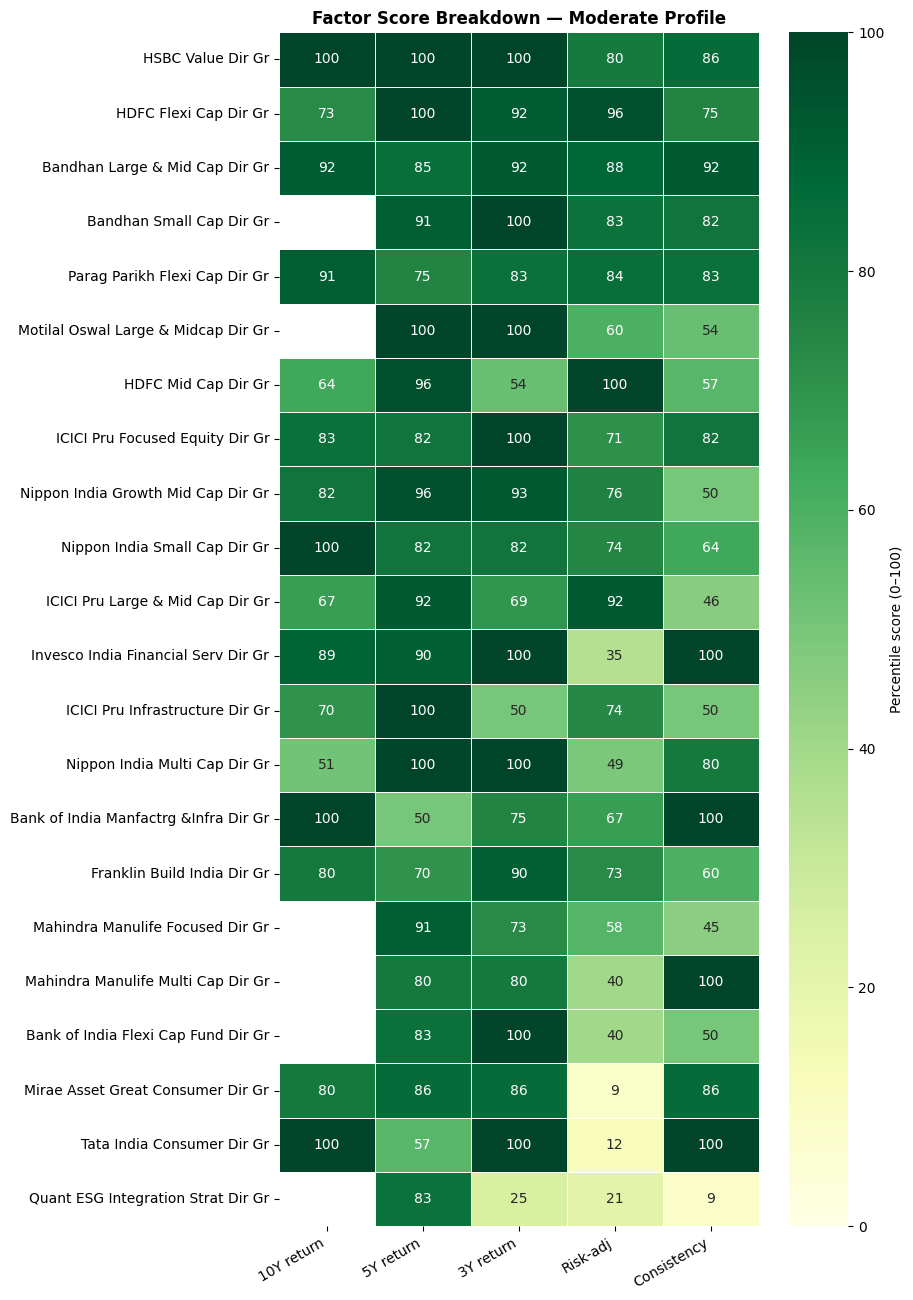

In [21]:
# ── Factor score heatmap ─────────────────────────────────────────────────────
heat = portfolio.set_index("Fund")[FACTOR_COLS].astype(float)

fig, ax = plt.subplots(figsize=(9, max(3, len(portfolio) * 0.55 + 1)))
sns.heatmap(
    heat, annot=True, fmt=".0f", cmap="YlGn",
    vmin=0, vmax=100, linewidths=0.4, ax=ax,
    cbar_kws={"label": "Percentile score (0–100)"},
)
ax.set_title(f"Factor Score Breakdown — {PROFILE.capitalize()} Profile",
             fontsize=12, fontweight="bold")
ax.set_xticklabels(
    ["10Y return", "5Y return", "3Y return", "Risk-adj", "Consistency"],
    rotation=30, ha="right",
)
ax.set_ylabel("")
plt.tight_layout()
plt.show()


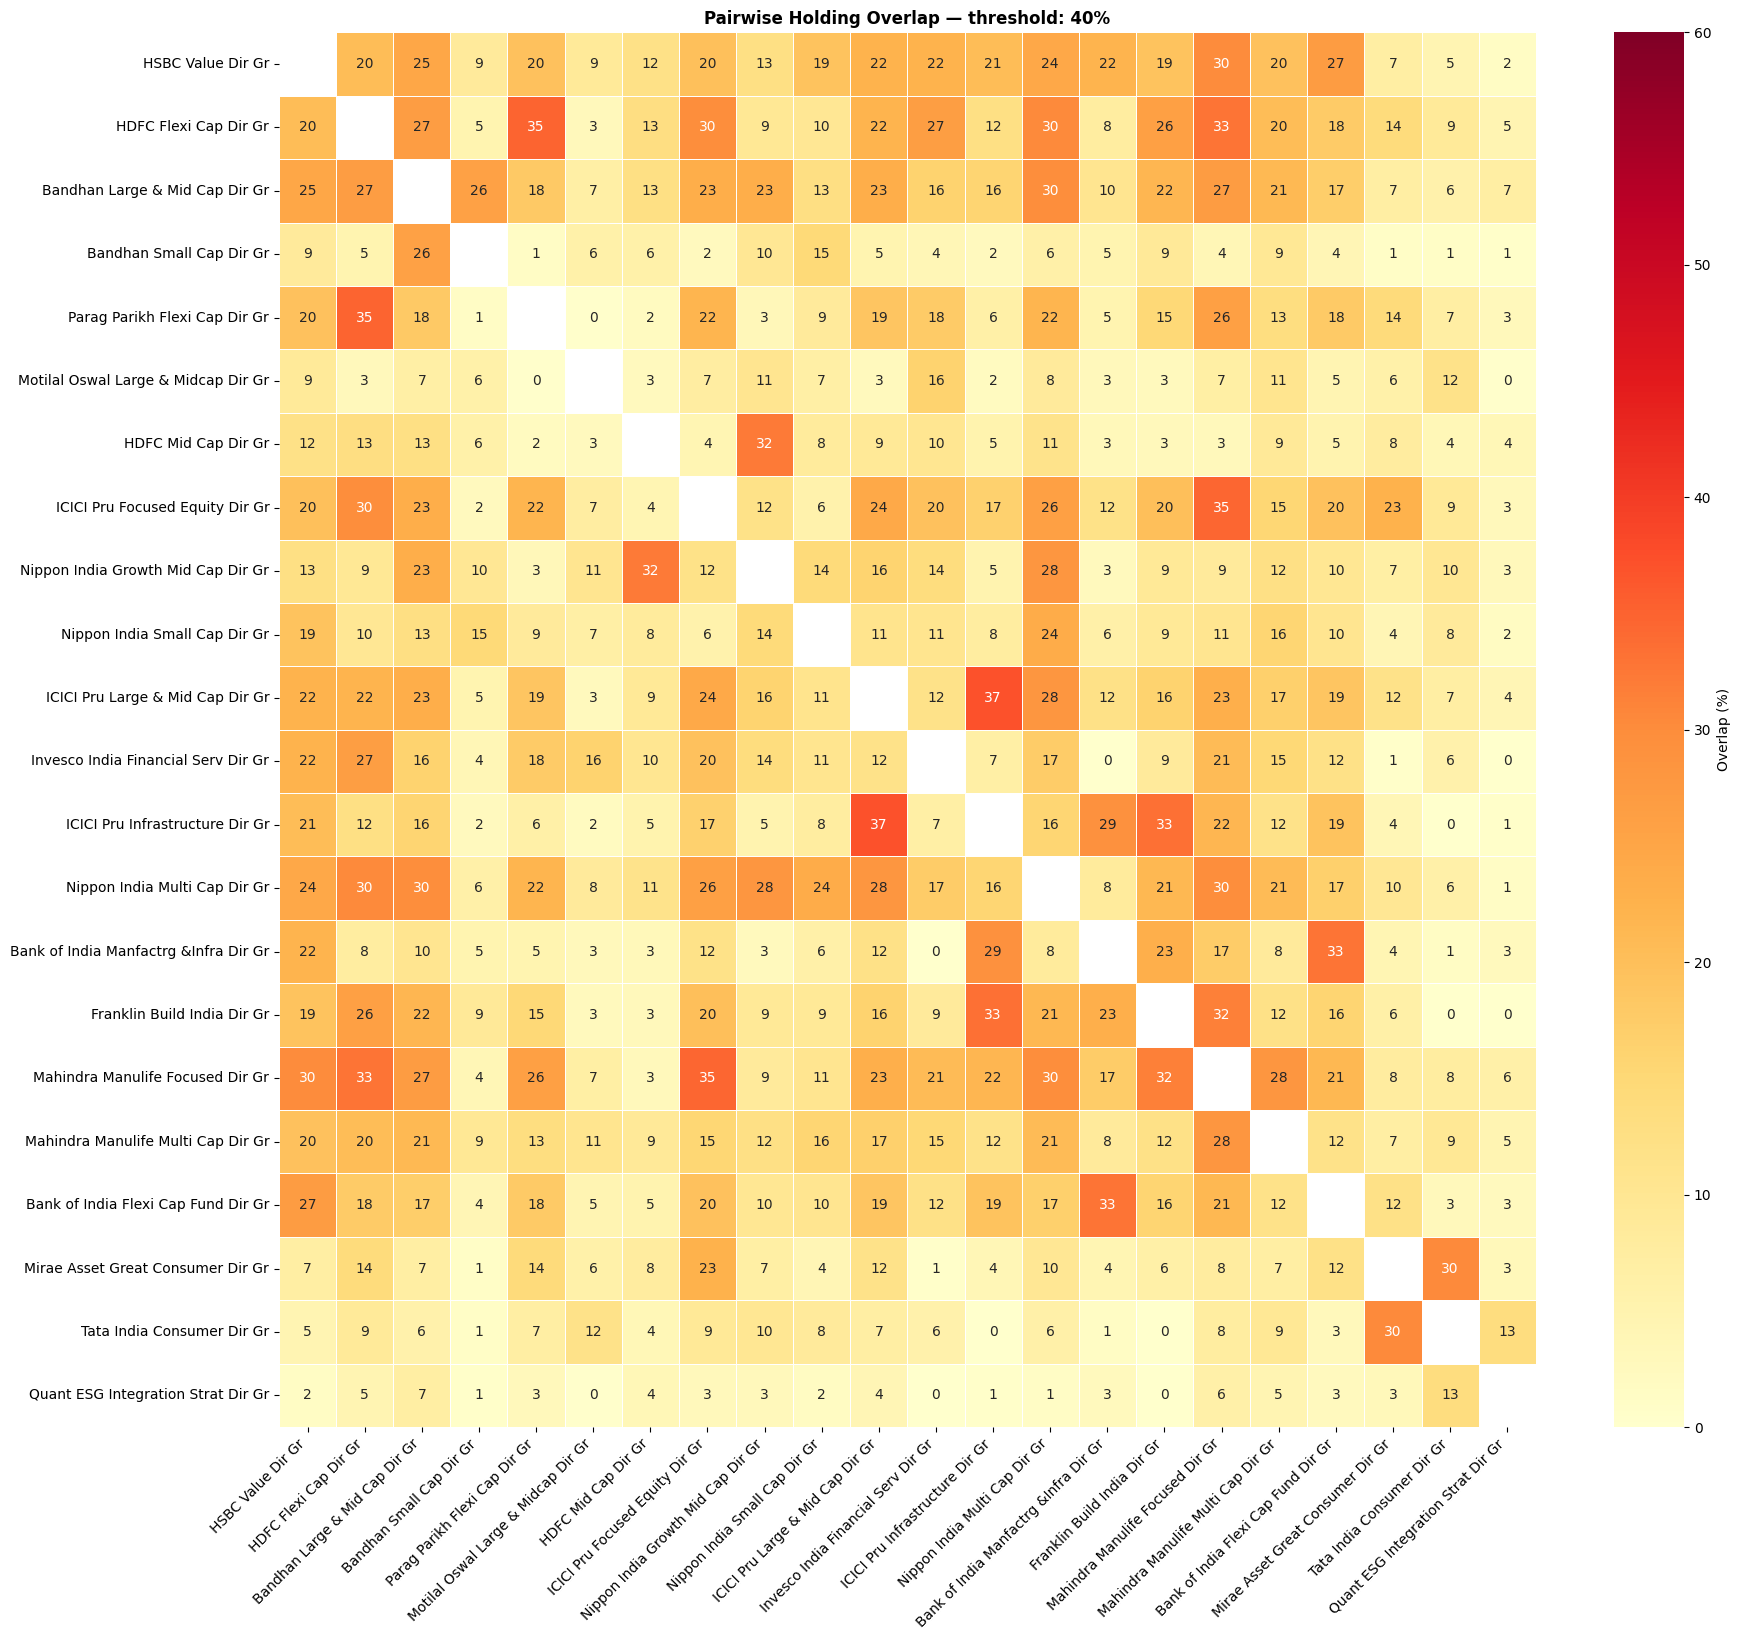

Max pairwise overlap in portfolio : 37.1%
Mean pairwise overlap             : 12.6%


In [22]:
# ── Pairwise overlap heatmap (selected funds only) ───────────────────────────
sel_isins = portfolio["isin"].tolist()
sel_names = portfolio["Fund"].tolist()
ov_sel    = overlap_df.loc[sel_isins, sel_isins].copy()
ov_sel.index   = sel_names
ov_sel.columns = sel_names

diag_mask = np.eye(len(sel_names), dtype=bool)

fig, ax = plt.subplots(figsize=(max(6, len(sel_names) * 0.85),
                                max(5, len(sel_names) * 0.75)))
sns.heatmap(
    ov_sel, annot=True, fmt=".0f", cmap="YlOrRd",
    vmin=0, vmax=60, mask=diag_mask,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Overlap (%)"},
)
ax.set_title(
    f"Pairwise Holding Overlap — threshold: {OVERLAP_THRESHOLD:.0f}%",
    fontsize=12, fontweight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

off_diag = ov_sel.values[~diag_mask]
print(f"Max pairwise overlap in portfolio : {off_diag.max():.1f}%")
print(f"Mean pairwise overlap             : {off_diag.mean():.1f}%")


In [23]:
# ── Export final portfolio to TSV ────────────────────────────────────────────
out_path = DATA_DIR / f"portfolio_{PROFILE}.tsv"
portfolio.drop(columns=["allocation"]).to_csv(out_path, sep="\t", index=False)
print(f"Portfolio saved to: {out_path}")


Portfolio saved to: portfolio_moderate.tsv
